In [139]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

In [140]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import time
from pprint import pprint

# importing Qiskit
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

# import basic plot tools
from qiskit.visualization import plot_histogram

Defining F gate operation

In [141]:
# Here, two useful routine
# Define a F_gate
def F_gate(circ,q,i,j,n,k) :
    theta = np.arccos(np.sqrt(1/(n-k+1)))
    circ.ry(-theta,q[j])       
    circ.cz(q[i],q[j])
    circ.ry(theta,q[j])
    circ.barrier(q[i])
# Define the cxrv gate which uses reverse CNOT instead of CNOT
def  cxrv(circ,q,i,j) :
    circ.h(q[i])
    circ.h(q[j])
    circ.cx(q[j],q[i])
    circ.h(q[i])
    circ.h(q[j])
    circ.barrier(q[i],q[j])

Creation of 4 qubit W state

In [142]:
# ----------------------------
# Create 4-qubit W state
# ----------------------------

n = 4

q = QuantumRegister(n, 'q')
c = ClassicalRegister(n, 'c')

W_states = QuantumCircuit(q, c)

# Initial state |0001>
W_states.x(q[3])
W_states.barrier()

# Apply your custom gates
F_gate(W_states, q, 3, 2, 4, 1)
F_gate(W_states, q, 2, 1, 4, 2)
F_gate(W_states, q, 1, 0, 4, 3)
W_states.barrier()

cxrv(W_states, q, 2, 3)
cxrv(W_states, q, 1, 2)
cxrv(W_states, q, 0, 1)


In [143]:
message = "0010"  # 0000,0001,0010,0011,0100,0101,0110,0111
# ----------------------------------------------------------
# Alice Encoding
# ----------------------------------------------------------

if message == "0000":
    W_states.z(1)

elif message == "0001":
    W_states.y(1)

elif message == "0010":
    W_states.z(0)

elif message == "0011":
    W_states.z(0)
    W_states.x(1)

elif message == "0100":
    W_states.x(0)

elif message == "0101":
    W_states.x(0)
    W_states.x(1)

elif message == "0110":
    W_states.y(0)
    W_states.z(1)

elif message == "0111":
    W_states.y(0)
    W_states.y(1)

W_states.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(<Qubit register=(4, "q"), index=0>, <Qubit register=(4, "q"), index=1>, <Qubit register=(4, "q"), index=2>, <Qubit register=(4, "q"), index=3>), clbits=())

In [144]:
# ----------------------------------------------------------
# Bob Decoding
# ----------------------------------------------------------
cxrv(W_states, q, 0, 1)
cxrv(W_states, q, 1, 2)
cxrv(W_states, q, 2, 3)
W_states.barrier()

F_gate(W_states, q, 1, 0, 4, 3)
F_gate(W_states, q, 2, 1, 4, 2)
F_gate(W_states, q, 3, 2, 4, 1)

# Measurements
W_states.measure(q, c)

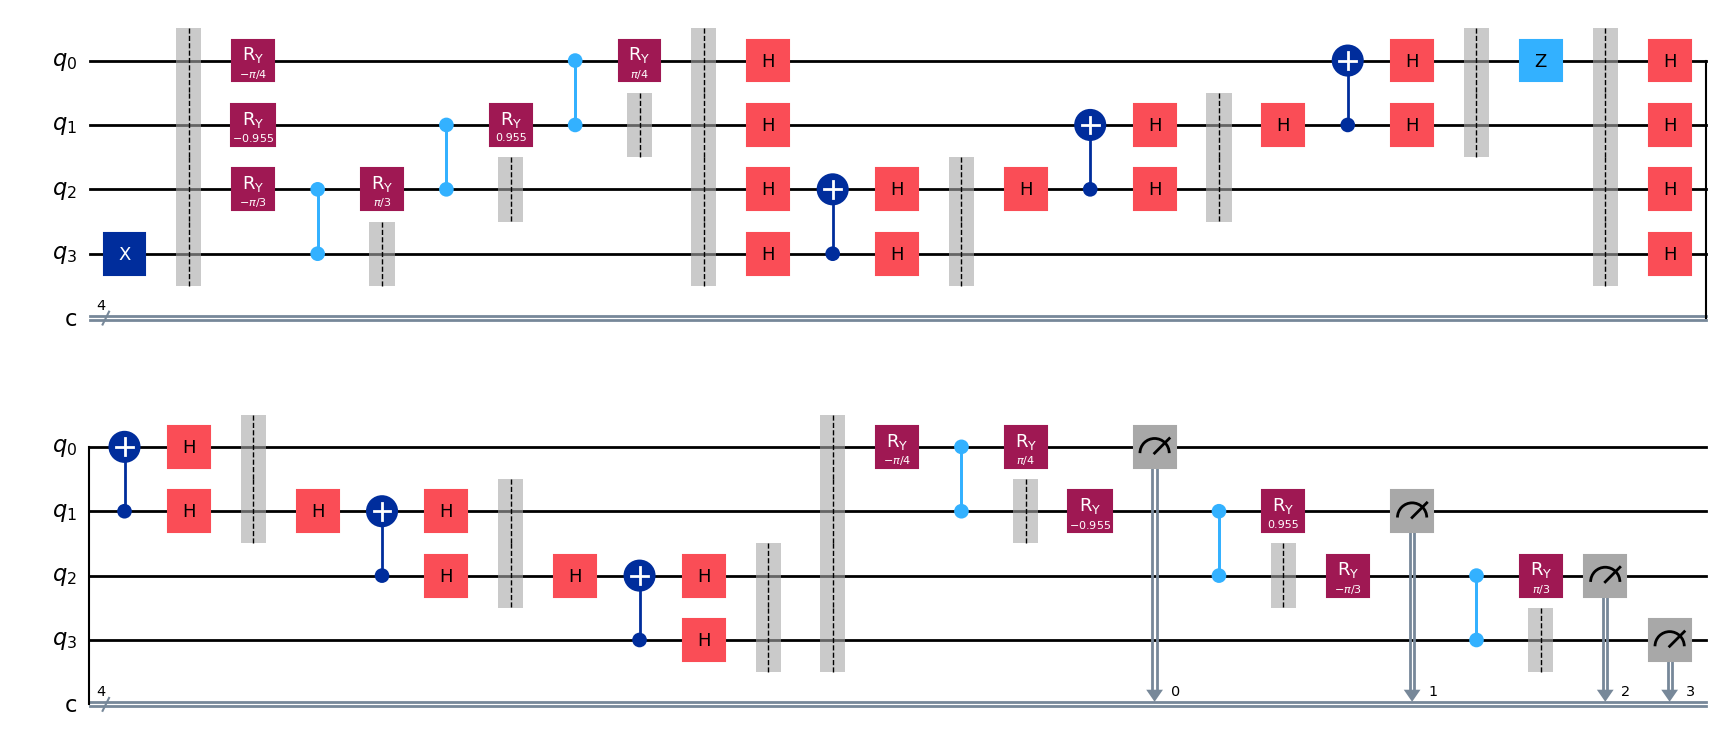

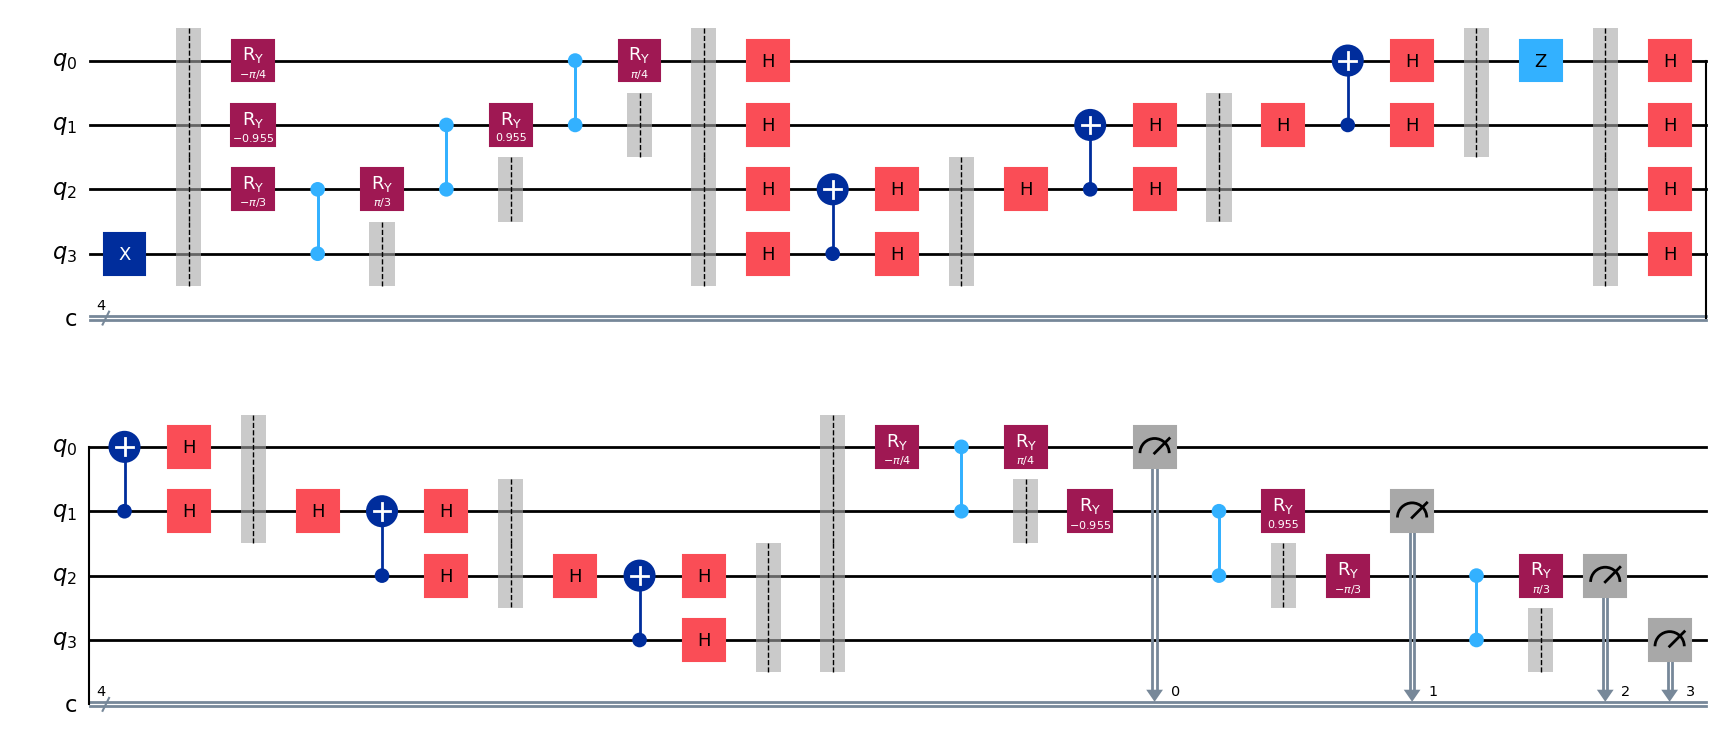

In [145]:
W_states.draw(output="mpl")

{'0000': 0, '0001': 0, '0010': 0, '0011': 0, '0100': 0, '0101': 0, '0110': 0, '0111': 0, '1000': 266, '1001': 254, '1010': 127, '1011': 134, '1100': 80, '1101': 78, '1110': 37, '1111': 48}


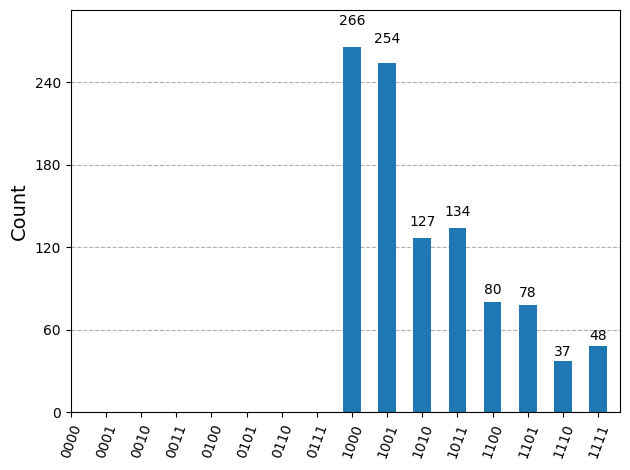

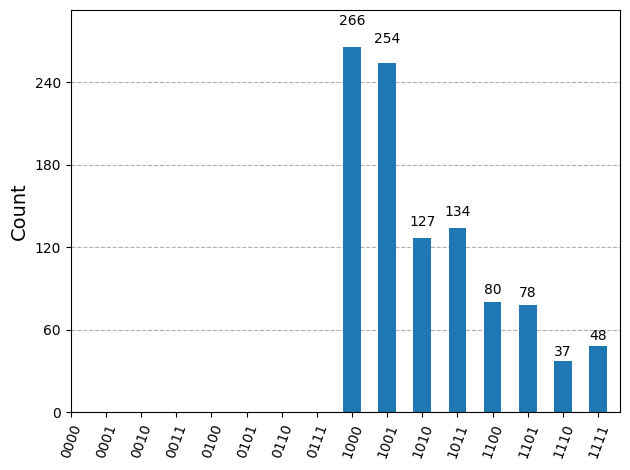

In [146]:
simulator = Aer.get_backend('qasm_simulator')

result = simulator.run(W_states, shots=1024).result()
counts = result.get_counts()

# Add missing states with zero counts
all_states = ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']

counts_complete = {state: counts.get(state, 0) for state in all_states}

print(counts_complete)

plot_histogram(counts_complete)